In [205]:
import h5py
import pandas as pd
import numpy as np

import plotly.graph_objects as go
import plotly.express as px

import matplotlib.pyplot as plt
from flymetrics import epochs

from src import io, vis, timesync
import xarray as xr
from src.plots import plot_PSTH
from src.plots import *
from src.xarray_ops import stack_epochs
from sklearn.decomposition import PCA
import seaborn as sns

In [2]:
# set raw and processed_paths
# define experiment id
exp_id = 'TSeries_20251217-101'

raw_path = io.get_base_path(exp_id,'raw')
processed_path = io.get_base_path(exp_id, 'processed')
print(raw_path)

/Volumes/AhmedLab/princess/data/raw/TSeries_20251217-101


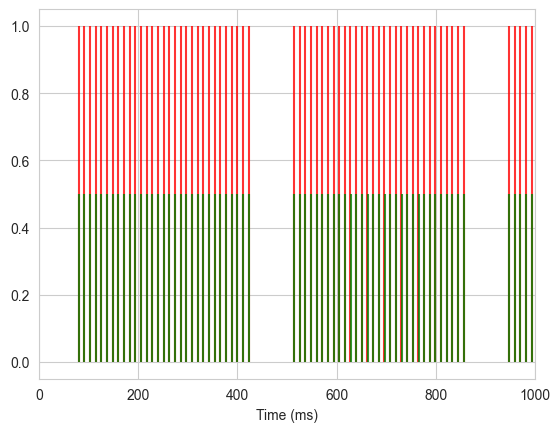

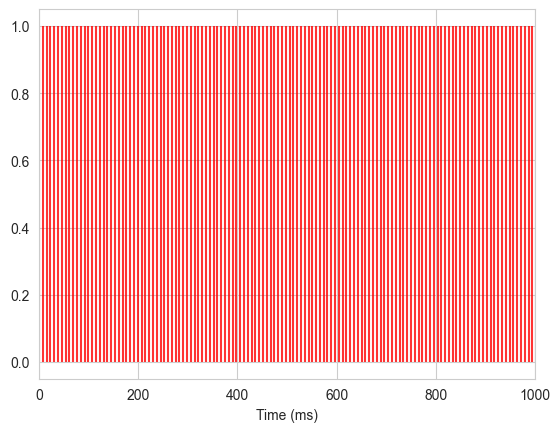

In [3]:
# load in scope timestamp data
scope_timestamps = timesync.extract_scope_timestamps(raw_path, plot=True)
camera_timestamps = timesync.extract_camera_timestamps(raw_path, plot=True)
# load in calcium and spatial data
cluster_labels, signal = io.load_clusters(processed_path)
scope_fr, camera_fr, brain_dim = io.load_acquisition_params(processed_path)

In [145]:
# convert all times to datetime format
# event times
walk_times = [
'00:37',
'00:50',
'01:12',
'2:10',
'2:47',
'8:15',
'8:29',
'9:02',
'11:48',
'11:14'
    ]

# reformat strings into event times in ms
t0 = np.datetime64('2025-01-01T00:00:00')
walk_events = np.asarray([int(e.split(':')[0])*60 + int(e.split(':')[1]) for e in walk_times])
walk_events = (walk_events * 1000).astype('<m8[ms]')
walk_events = t0+walk_events

# organize into dataframe
# epoch_df stores all events of interest
walk_epoch_df = pd.DataFrame(walk_events, columns=['start'])
walk_epoch_df['epoch'] = 'walk' # this just fills in walk into epoch column of each behavior, but should be changed for other behaviors
walk_epoch_df['stop'] = walk_epoch_df['start'] + np.timedelta64(5, 's')
walk_epoch_df

,start,epoch,stop
0,2025-01-01 00:00:37,walk,2025-01-01 00:00:42
1,2025-01-01 00:00:50,walk,2025-01-01 00:00:55
2,2025-01-01 00:01:12,walk,2025-01-01 00:01:17
3,2025-01-01 00:02:10,walk,2025-01-01 00:02:15
4,2025-01-01 00:02:47,walk,2025-01-01 00:02:52
5,2025-01-01 00:08:15,walk,2025-01-01 00:08:20
6,2025-01-01 00:08:29,walk,2025-01-01 00:08:34
7,2025-01-01 00:09:02,walk,2025-01-01 00:09:07
8,2025-01-01 00:11:48,walk,2025-01-01 00:11:53
9,2025-01-01 00:11:14,walk,2025-01-01 00:11:19


In [146]:
flap_times = [
'4:22',
'6:13',
'11:41',
'12:00',
'12:17',
'12:30',
'13:02',
'13:41',
'13:54',
'14:43',
    ]

flap_events = np.asarray([int(e.split(':')[0])*60 + int(e.split(':')[1]) for e in flap_times])
flap_events = (flap_events * 1000).astype('<m8[ms]')
flap_events = t0+flap_events

flap_epoch_df = pd.DataFrame(flap_events, columns=['start'])
flap_epoch_df['epoch'] = 'flap' # this just fills in walk into epoch column of each behavior, but should be changed for other behaviors
flap_epoch_df['stop'] = flap_epoch_df['start'] + np.timedelta64(5, 's')
flap_epoch_df

,start,epoch,stop
0,2025-01-01 00:04:22,flap,2025-01-01 00:04:27
1,2025-01-01 00:06:13,flap,2025-01-01 00:06:18
2,2025-01-01 00:11:41,flap,2025-01-01 00:11:46
3,2025-01-01 00:12:00,flap,2025-01-01 00:12:05
4,2025-01-01 00:12:17,flap,2025-01-01 00:12:22
5,2025-01-01 00:12:30,flap,2025-01-01 00:12:35
6,2025-01-01 00:13:02,flap,2025-01-01 00:13:07
7,2025-01-01 00:13:41,flap,2025-01-01 00:13:46
8,2025-01-01 00:13:54,flap,2025-01-01 00:13:59
9,2025-01-01 00:14:43,flap,2025-01-01 00:14:48


In [148]:
# converting scope timestamps into datetime format
t0 = np.datetime64('2025-01-01T00:00:00')
# because scope_timestamps is for single slices, we selected the first slice of the volume to use as our timestamps
# to align to signal timestamps
deltas = np.round(scope_timestamps[::31]).astype('<m8[ms]')
timestamps = t0+deltas

In [150]:
# transform my signal array into xarray with named columns
signal_xary = xr.DataArray(
    data=signal,
    dims=['zposs', 'roi', 'time'],
    coords={'time': timestamps.squeeze()},
)

# transform signal and event times into epoch xarray
walks = stack_epochs(
    xary=signal_xary,
    epochs=['walk'],
    epoch_df=walk_epoch_df,
    start_shift=np.timedelta64(-2, 's'),
    end_shift=np.timedelta64(10, 's'),
    mode='start'
)
walks = walks.squeeze()

# transform signal and event times into epoch xarray
flaps = stack_epochs(
    xary=signal_xary,
    epochs=['flap'],
    epoch_df=flap_epoch_df,
    start_shift=np.timedelta64(-2, 's'),
    end_shift=np.timedelta64(10, 's'),
    mode='start'
)
flaps = flaps.squeeze()

/Users/princesst/projects/maui_codebook/src/xarray_ops.py:158: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  trial_stack = xr.concat(
/Users/princesst/projects/maui_codebook/src/xarray_ops.py:158: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  trial_stack = xr.concat(


In [151]:
to_pca = signal_xary.stack(poss=['zposs','roi'])
to_pca -= to_pca.mean(dim='time')
to_pca = to_pca.dropna(dim='time', how='any')

[52.84092625 21.54886009  7.99208523  6.47917507  3.0152352   2.19360047
  2.01345658  1.75248117  1.14533399  1.01884595]


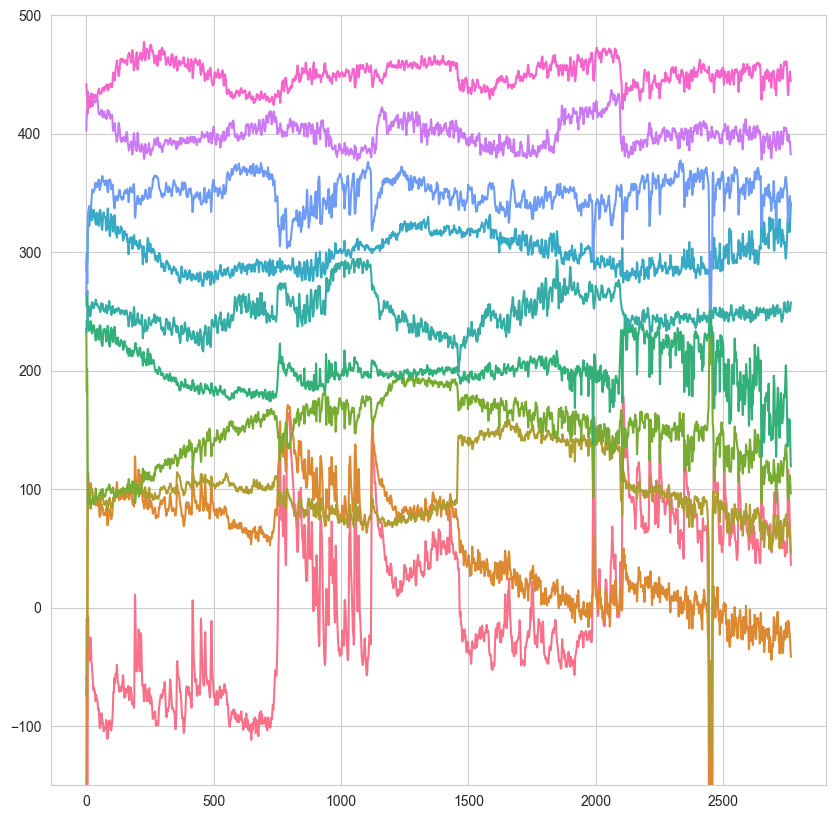

In [211]:
pca = PCA(n_components=10)

# fit my data to the 50 PCA components
all_transformed = pca.fit_transform(to_pca.transpose('time', 'poss'))
print(pca.explained_variance_ / np.sum(pca.explained_variance_)*100)

fig, ax = plt.subplots(figsize=(10,10))
color_list = sns.color_palette('husl', n_colors=10)
yshift = 50
ax.set_ylim(-150,500)
for idx, ind_cluster in enumerate(all_transformed.T):
    ax.plot(ind_cluster +(idx*yshift), color=color_list[idx])

In [174]:
all_transformed
pca_transforms = xr.DataArray(
    data=all_transformed,
    dims=['time', 'pcs'],
    coords={'time': timestamps.squeeze()}
)
pca_transforms

<xarray.DataArray (time: 2767, pcs: 10)> Size: 221kB
array([[-516.1140409 , -199.36906015, -174.39566018, ...,  -86.71878954,
           2.50992851,   -7.87377067],
       [-378.52710036, -133.62587894, -128.01012675, ...,  -68.43769589,
          10.97118525,  -13.16622052],
       [-315.89027081, -108.59800197, -108.94267699, ...,  -54.62054348,
          18.81623986,  -17.14040634],
       ...,
       [  53.74362144,  -84.51610727,  -45.55369647, ...,   -9.95195624,
         -13.13268392,   -2.51560017],
       [  42.64722062,  -89.52421534,  -51.41072906, ...,  -11.13681253,
         -16.32567315,   -5.03479382],
       [  35.87154459,  -91.65209887,  -54.0168205 , ...,   -8.51856137,
         -17.51631598,   -5.4435799 ]], shape=(2767, 10))
Coordinates:
  * time     (time) datetime64[ms] 22kB 2025-01-01T00:00:00.080000 ... 2025-0...
Dimensions without coordinates: pcs

In [159]:
pca_walks = stack_epochs(
    xary=pca_transforms,
    epochs=['walk'],
    epoch_df=walk_epoch_df,
    start_shift=np.timedelta64(-2, 's'),
    end_shift=np.timedelta64(5, 's'),
)
pca_flaps = stack_epochs(
    xary=pca_transforms,
    epochs=['flap'],
    epoch_df=flap_epoch_df,
    start_shift=np.timedelta64(-2, 's'),
    end_shift=np.timedelta64(5, 's'),
)

/Users/princesst/projects/maui_codebook/src/xarray_ops.py:158: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  trial_stack = xr.concat(
/Users/princesst/projects/maui_codebook/src/xarray_ops.py:158: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  trial_stack = xr.concat(


In [183]:
pca_walks = pca_walks.squeeze()
pca_flaps = pca_flaps.squeeze()

Text(0.5, 1.0, 'PC calcium response during flapping state')

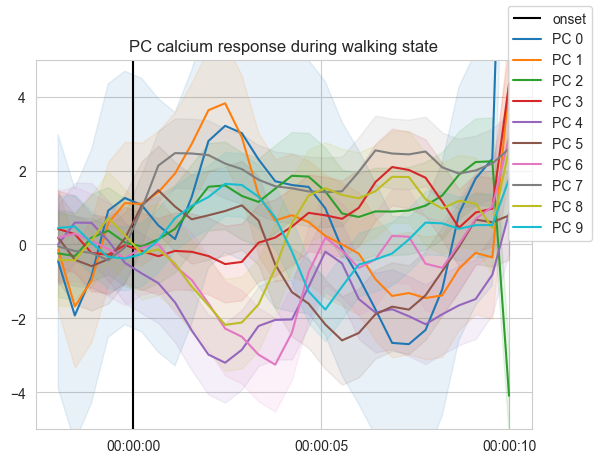

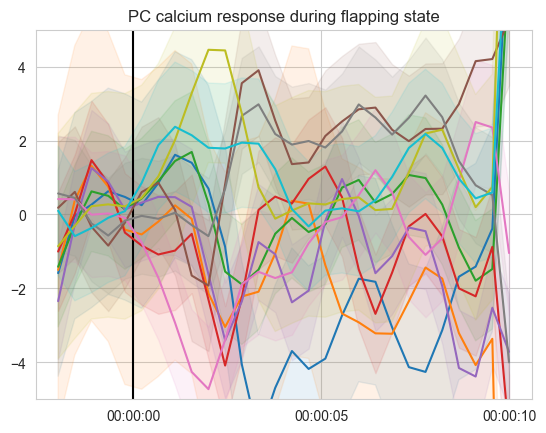

In [229]:
# calculate mean and time coordinates
# FOR WALKING:
walk_psth = pca_walks.mean(dim='trial')
time = walk_psth.coords['time']
# reduce dimensions
walk_psth = walk_psth.squeeze()

# FOR FLAPPING:
flap_psth = pca_flaps.mean(dim='trial')
time = flap_psth.coords['time']
# reduce dimensions
flap_psth = flap_psth.squeeze()

color_list = sns.color_palette('tab10', n_colors=10)

fig, ax = plt.subplots()
onset = np.datetime64('2025-01-01T00:00:00')
ax.vlines(onset, ymin=-10, ymax=10, color='k', label='onset')
# ax.legend(loc='upper right')

for pc in range(walk_psth.shape[1]):
    # calculate mean df/f prelocomotion
    pre = walk_psth.sel(pos=pc).isel(time=slice(0,6)).mean(dim='time')
    # subtract baseline from trace
    normalized_trace = walk_psth.sel(pos=pc) - pre
    err = normalized_trace.std(dim='time')

    ax.plot(time, normalized_trace, color=color_list[pc], label = f'PC {pc}')
    ax.set_ylim(-5,5)
    ax.fill_between(time, normalized_trace+err,normalized_trace-err, color=color_list[pc], alpha=0.1)
ax.set_title('PC calcium response during walking state')
fig.legend(loc='outside upper right')

fig2, ax2 = plt.subplots()
onset = np.datetime64('2025-01-01T00:00:00')
ax2.vlines(onset, ymin=-10, ymax=10, color='k', label='onset')


for pc in range(flap_psth.shape[1]):
    # calculate mean df/f prelocomotion
    pre = flap_psth.sel(pos=pc).isel(time=slice(0,6)).mean(dim='time')
    # subtract baseline from trace
    normalized_trace = flap_psth.sel(pos=pc) - pre
    err = normalized_trace.std(dim='time')

    ax2.plot(time, normalized_trace, color=color_list[pc], label = f'PC {pc}')
    ax2.set_ylim(-5,5)
    ax2.fill_between(time, normalized_trace+err,normalized_trace-err , color=color_list[pc], alpha=0.1)
ax2.set_title('PC calcium response during flapping state')
# ax2.legend(loc='upper right')
# fig2.legend(loc='outside upper right')